# investigate component similarity various ways

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from jaxtyping import Float, Int

from spd.models.component_model import ComponentModel, Config
from spd.models.component_utils import calc_component_acts, calc_masks
from spd.models.components import (
    AnyComponent,
    AnyGate,
)
from spd.plotting import plot_mask_vals

torch.set_grad_enabled(False)
# Set your model path here
# TODO: make this more general
# MODEL_PATH = "spd/experiments/tms/out/randrecon1.00e+00_p1.00e+00_lpsp1.00e-04_m200_sd0_lr1.00e-03_bs4096_ft40_hid10hid-layers1_20250609_151342_824/model_40000.pth" # noqa: E501
MODEL_PATH = "../spd/experiments/tms/out/randrecon1.00e+00_p2.00e+00_lpsp1.00e-04_m50_sd0_lr1.00e-03_bs4096_ft40_hid10hid-layers1_20250617_195956_677/model_10000.pth"  # noqa: E501

DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Load the decomposition model
model: ComponentModel
config: Config
model, config, _ = ComponentModel.from_pretrained(MODEL_PATH)

# Extract components and gates for plotting
components: dict[str, AnyComponent] = {
    k: v for k, v in model.components.items() if hasattr(v, "A") and hasattr(v, "B")
}  # type: ignore
gates: dict[str, AnyGate] = {k: v for k, v in model.gates.items()}

# Get the input shape from your TMS config
n_features: int = 40
model = model.to(DEVICE)

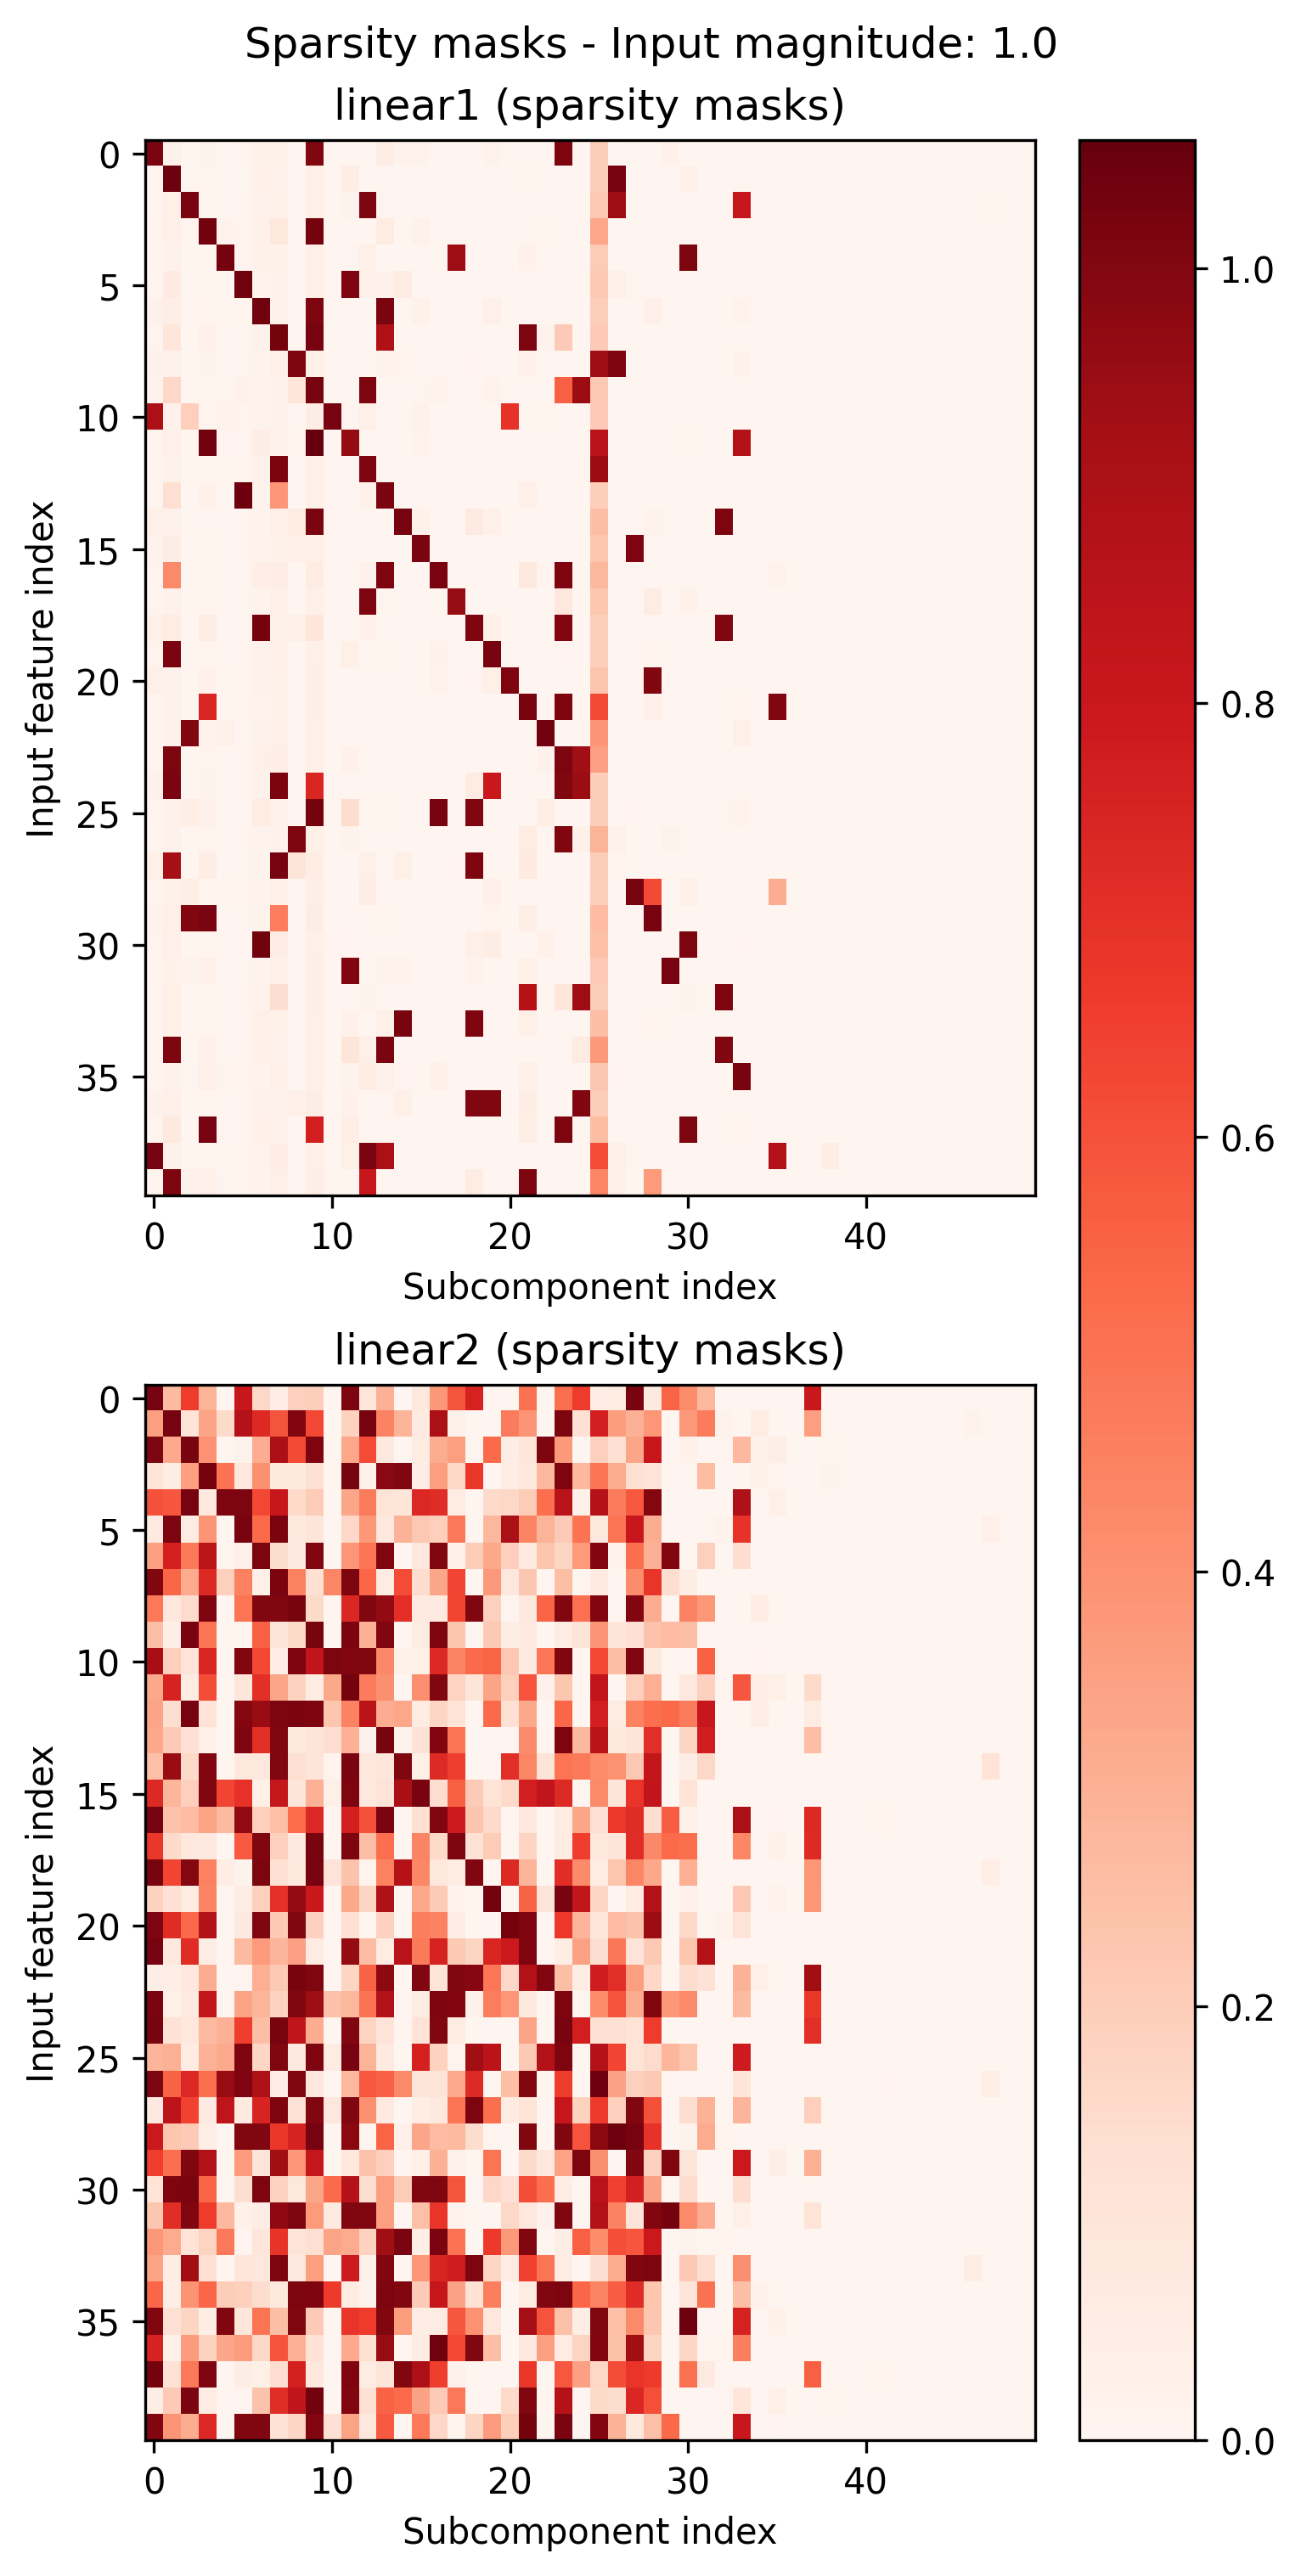

In [3]:
# Generate the mask plots with single feature inputs (one-hot vectors)
figures, perm_indices = plot_mask_vals(
    model=model,
    components=components,
    gates=gates,
    batch_shape=(n_features,),
    device=DEVICE,
    input_magnitude=1.0,
    plot_regular_masks=False,  # Only plot sparsity masks (red plots)
)